### RaschPy RSM worked example

This notebook works through a sample Rasch analysis of a simulated data set (1,000 persons, 8 items with a maximum score of 5, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected — if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.RSM_Sim(no_of_items=8, no_of_persons=80, max_score=4, seed=99)
responses_disconnected = sim_disconnected.responses.copy()
responses_disconnected.iloc[:40, 4:] = float('nan')   # first 40 persons: only answer items 1-4
responses_disconnected.iloc[40:, :4] = float('nan')    # last 40 persons: only answer items 5-8

broken_rsm = rp.RSM(responses_disconnected, max_score=4)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/rsm.py:209: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_97483/2776287308.py:6: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_rsm = rp.RSM(responses_disconnected, max_score=4)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_rsm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': [],
 'strongly_connected': False}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=999` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set. 12 items, 1,000 persons, no missing data.

In [4]:
sim = rp.RSM_Sim(no_of_items=12, no_of_persons=500, max_score=5, missing=0, seed=9999)
sim.responses.to_csv('rsm_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_rsm()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_rsm('rsm_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Person_1,2.0,2.0,3.0,2.0,3.0,2.0,4.0,4.0,3.0,2.0,2.0,2.0
Person_2,2.0,2.0,3.0,2.0,3.0,2.0,3.0,3.0,4.0,3.0,3.0,3.0


Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12


Create an RSM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `rsm.generating`, which lets us check parameter recovery further down, and also means `max_score` doesn't need to be supplied again. If you're analysing your own data, pass a DataFrame and `max_score` instead (e.g. `rp.RSM(data, max_score)`).

In [8]:
rsm = rp.RSM(sim)

Generate item estimates. The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
rsm.calibrate()

CPU times: user 1.89 ms, sys: 328 μs, total: 2.22 ms
Wall time: 2.03 ms


Check the item location estimates

In [10]:
rsm.items

Item_1     1.426247
Item_2     0.697436
Item_3    -0.683337
Item_4     1.371821
Item_5     0.473896
Item_6     0.489968
Item_7    -1.634323
Item_8    -1.341870
Item_9     0.221644
Item_10   -1.552996
Item_11   -0.121436
Item_12    0.652949
dtype: float64

Since this is simulated data, we know the true generating item locations (`rsm.generating.items`) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE:

In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')


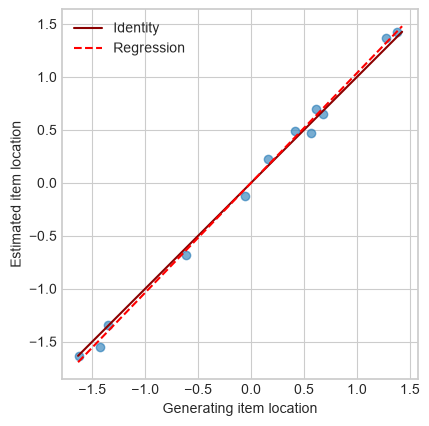

item location Pearson correlation:              0.998
item location SD ratio (estimated / generating): 1.039
item location regression coefficient:            1.037
item location RMSE:                              0.072


In [12]:
recovery_plot(rsm.generating.items, rsm.items, 'item location', 'my_rsm_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [13]:
%%time
rsm.item_stats_df(full=True)
rsm.item_stats.to_csv('rsm_item_stats.csv')

CPU times: user 1.11 s, sys: 27.6 ms, total: 1.14 s
Wall time: 1.14 s


Check the item statistics table

In [14]:
rsm.item_stats

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,PM corr,Exp PM corr
Item_1,1.426,0.088,1.264,1.611,500,0.399,0.822,-3.002,0.825,-2.946,0.723,0.707
Item_2,0.697,0.080,0.553,0.843,500,0.453,0.914,-1.396,0.917,-1.330,0.718,0.709
Item_3,-0.683,0.081,-0.839,-0.531,500,0.556,0.954,-0.734,0.948,-0.835,0.703,0.699
Item_4,1.372,0.077,1.236,1.533,500,0.404,0.787,-3.636,0.786,-3.670,0.757,0.707
Item_5,0.474,0.080,0.311,0.627,500,0.464,0.940,-0.965,0.943,-0.900,0.718,0.708
Item_6,0.490,0.081,0.314,0.648,500,0.462,1.035,0.572,1.021,0.359,0.703,0.708
Item_7,-1.634,0.088,-1.809,-1.479,500,0.628,0.871,-2.163,0.860,-2.298,0.714,0.683
Item_8,-1.342,0.088,-1.516,-1.175,500,0.607,0.895,-1.745,0.879,-1.988,0.723,0.689
Item_9,0.222,0.077,0.069,0.370,500,0.488,0.926,-1.204,0.918,-1.320,0.740,0.708
Item_10,-1.553,0.086,-1.724,-1.395,500,0.620,0.846,-2.608,0.856,-2.376,0.729,0.685


Generate a table of threshold statistics (and check run time), and save to file

In [15]:
%%time
rsm.threshold_stats_df(full=True)
rsm.threshold_stats.to_csv('rsm_threshold_stats.csv')

CPU times: user 2.54 ms, sys: 661 μs, total: 3.2 ms
Wall time: 2.94 ms


Check the threshold statistics table

In [16]:
rsm.threshold_stats

,Estimate,SE,2.5%,97.5%,Infit MS,Infit Z,Outfit MS,Outfit Z,Discrim,PM corr,Exp PM corr
Threshold 1,-5.671,0.178,-5.840,-5.157,0.695,-3.048,0.579,-1.923,1.162,0.274,0.255
Threshold 2,-2.740,0.090,-2.878,-2.529,0.959,-1.677,0.928,-1.411,1.056,0.783,0.768
Threshold 3,-0.095,0.077,-0.235,0.064,0.947,-3.440,0.908,-3.406,1.118,1.143,1.060
Threshold 4,2.118,0.081,1.950,2.262,0.921,-3.517,0.837,-3.762,1.133,1.069,0.996
Threshold 5,6.387,0.215,5.749,6.601,0.672,-2.779,0.385,-2.199,1.165,0.313,0.295


And the same recovery check for the shared threshold vector, against `rsm.generating.thresholds`:

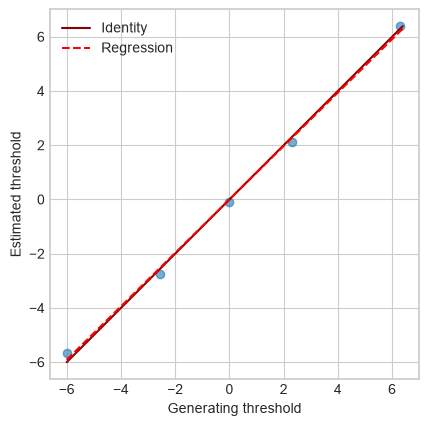

threshold Pearson correlation:              0.999
threshold SD ratio (estimated / generating): 0.986
threshold regression coefficient:            0.985
threshold RMSE:                              0.2


In [17]:
recovery_plot(rsm.generating.thresholds, rsm.thresholds, 'threshold', 'my_rsm_threshold_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [18]:
%%time
rsm.person_stats_df(full=True)
rsm.person_stats.to_csv('rsm_person_stats.csv')

CPU times: user 5.89 ms, sys: 950 μs, total: 6.84 ms
Wall time: 6.59 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [19]:
rsm.person_stats.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Infit Z,Outfit MS,Outfit Z
Person_1,0.028,0.456,0.425,31,60,0.517,0.867,-0.219,0.862,-0.233
Person_2,0.440,0.455,0.377,33,60,0.550,0.685,-0.791,0.667,-0.852
Person_3,0.645,0.456,0.448,34,60,0.567,0.963,0.030,0.947,-0.015
Person_4,0.234,0.455,0.449,32,60,0.533,0.973,0.060,0.977,0.071
Person_5,3.895,0.581,0.707,47,60,0.783,1.479,1.051,1.271,0.679
Person_6,-1.670,0.467,0.338,23,60,0.383,0.523,-1.325,0.525,-1.321
Person_7,-1.024,0.462,0.388,26,60,0.433,0.705,-0.671,0.704,-0.672
Person_8,-1.888,0.470,0.483,22,60,0.367,1.057,0.273,1.068,0.300
Person_9,2.427,0.505,0.465,42,60,0.700,0.851,-0.244,1.062,0.284
Person_10,0.028,0.456,0.618,31,60,0.517,1.840,1.840,1.817,1.796


And the same recovery check for person locations, against `rsm.generating.persons`:

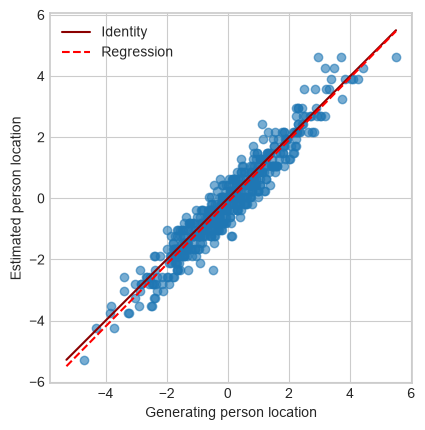

person location Pearson correlation:              0.96
person location SD ratio (estimated / generating): 1.059
person location regression coefficient:            1.017
person location RMSE:                              0.47


In [20]:
recovery_plot(rsm.generating.persons, rsm.persons, 'person location', 'my_rsm_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [21]:
%%time
rsm.test_stats_df()
rsm.test_stats.to_csv('rsm_test_stats.csv')

CPU times: user 1.08 ms, sys: 571 μs, total: 1.65 ms
Wall time: 1.36 ms


Check the test statistics table

In [22]:
rsm.test_stats

,Items,Persons
Mean,-0.000,-0.123
SD,1.075,1.622
Separation ratio,13.193,3.500
Strata,17.925,5.000
Reliability,0.994,0.925


Run a residual correlation analysis (and check run time), and save relevant output to file

In [23]:
%%time
rsm.res_corr_analysis()
rsm.residual_correlations.to_csv('rsm_residual_correlations.csv')
rsm.loadings.to_csv('rsm_loadings.csv')

CPU times: user 7.39 ms, sys: 2.14 ms, total: 9.53 ms
Wall time: 10.8 ms


View the table of pairwise standard residual correlations

In [24]:
round(rsm.residual_correlations, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Item_1,1.000,-0.101,-0.002,-0.173,-0.079,-0.101,-0.073,-0.132,-0.137,-0.036,-0.074,-0.051
Item_2,-0.101,1.000,-0.169,0.018,-0.128,-0.068,-0.074,-0.102,-0.101,-0.089,-0.064,-0.133
Item_3,-0.002,-0.169,1.000,-0.150,-0.108,-0.105,-0.005,-0.139,-0.032,-0.108,-0.144,-0.076
Item_4,-0.173,0.018,-0.150,1.000,-0.052,-0.115,-0.139,-0.007,-0.072,-0.087,-0.068,-0.088
Item_5,-0.079,-0.128,-0.108,-0.052,1.000,-0.082,-0.123,-0.095,-0.065,-0.127,-0.103,-0.071
Item_6,-0.101,-0.068,-0.105,-0.115,-0.082,1.000,-0.153,-0.106,-0.171,-0.095,-0.049,-0.049
Item_7,-0.073,-0.074,-0.005,-0.139,-0.123,-0.153,1.000,-0.043,-0.029,-0.047,-0.187,-0.085
Item_8,-0.132,-0.102,-0.139,-0.007,-0.095,-0.106,-0.043,1.000,-0.082,-0.115,-0.083,-0.078
Item_9,-0.137,-0.101,-0.032,-0.072,-0.065,-0.171,-0.029,-0.082,1.000,-0.120,-0.102,-0.114
Item_10,-0.036,-0.089,-0.108,-0.087,-0.127,-0.095,-0.047,-0.115,-0.120,1.000,-0.041,-0.082


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [25]:
round(rsm.loadings['PC 1'], 3)

Item_1     0.129
Item_2    -0.143
Item_3     0.213
Item_4    -0.182
Item_5    -0.020
Item_6    -0.069
Item_7     0.156
Item_8    -0.076
Item_9     0.057
Item_10    0.022
Item_11   -0.123
Item_12    0.045
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) for Item 2, with observed category means plotted and the central item location marked

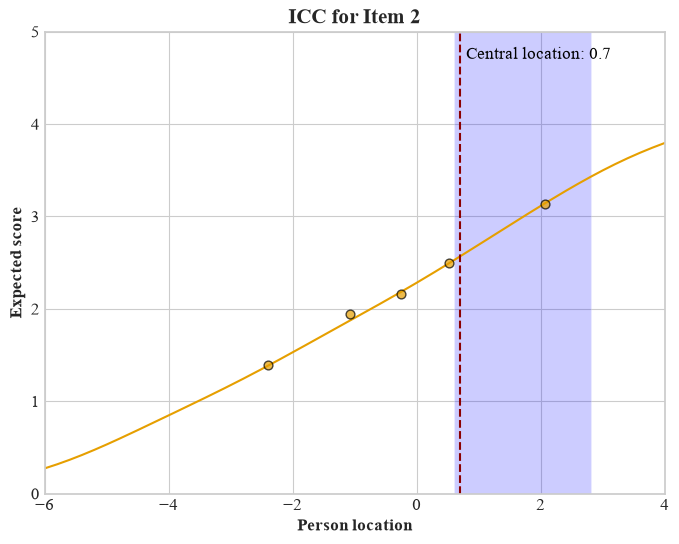

In [26]:
rsm.icc('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-6, xmax=4, filename='my_rsm_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

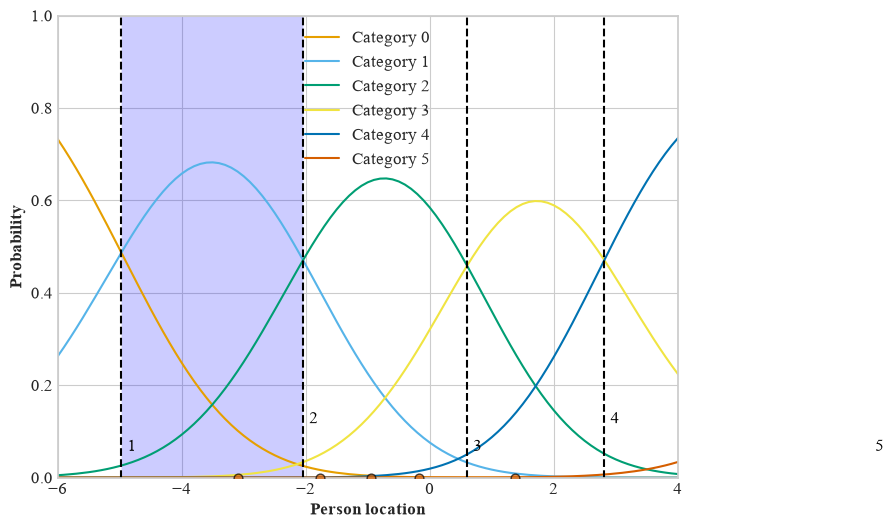

In [27]:
rsm.crcs('Item_2', thresh_lines=True, cat_highlight=1, obs=[5], xmin=-6, xmax=4, filename='my_rsm_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 5, category 1 highlighted and the thresholds marked

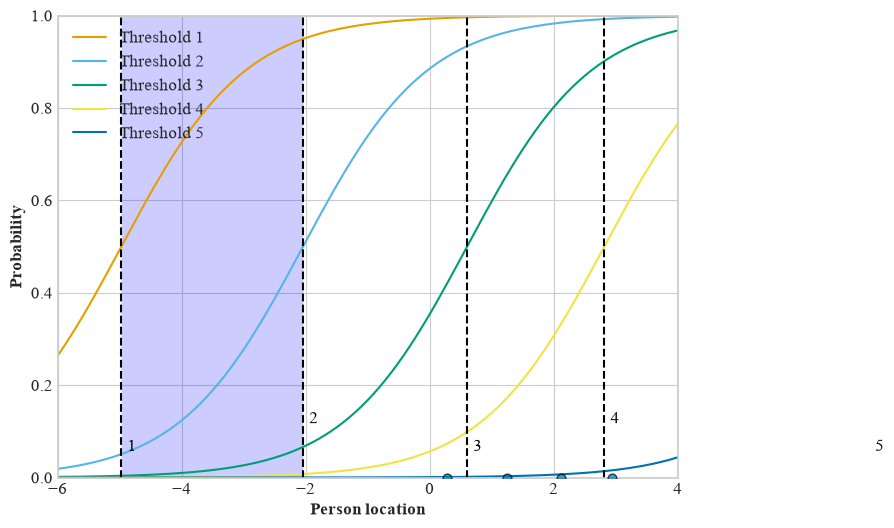

In [28]:
rsm.threshold_ccs('Item_2', thresh_lines=True, obs=[5], cat_highlight=1, xmin=-6, xmax=4, filename='my_rsm_threshold_ccs')

Produce an item information function curve for Item 2

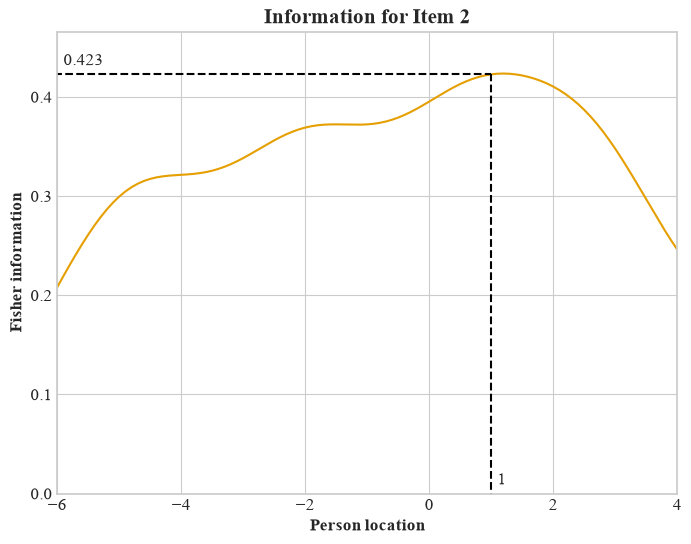

In [29]:
rsm.iic('Item_2', point_info_lines=[1], point_info_labels=True, title='Information for Item 2', xmin=-6, xmax=4, filename='my_rsm_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 20 and 30 plotted.

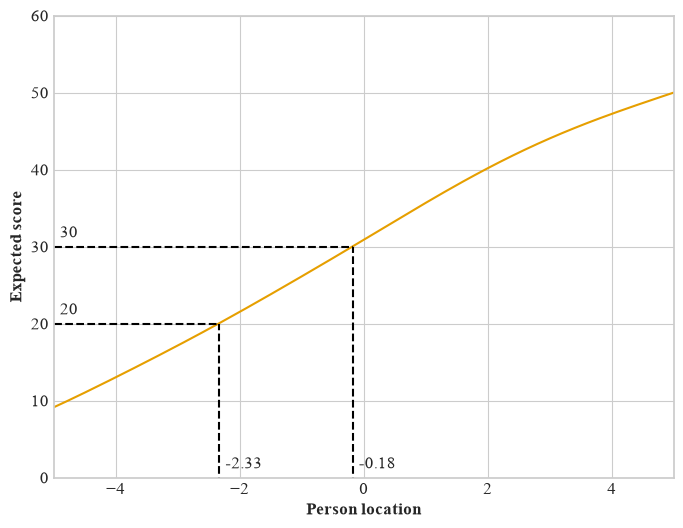

In [30]:
rsm.tcc(score_lines=[20, 30], score_labels=True, filename='my_rsm_tcc')

Produce a test information curve

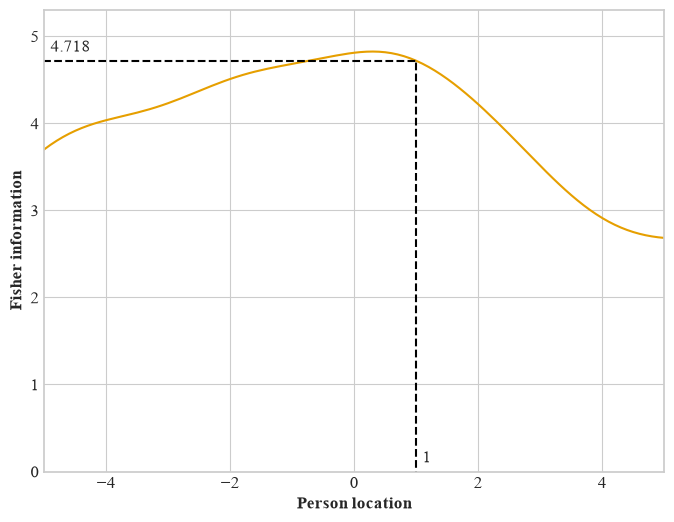

In [31]:
rsm.test_info(point_info_lines=[1], point_info_labels=True, filename='my_rsm_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

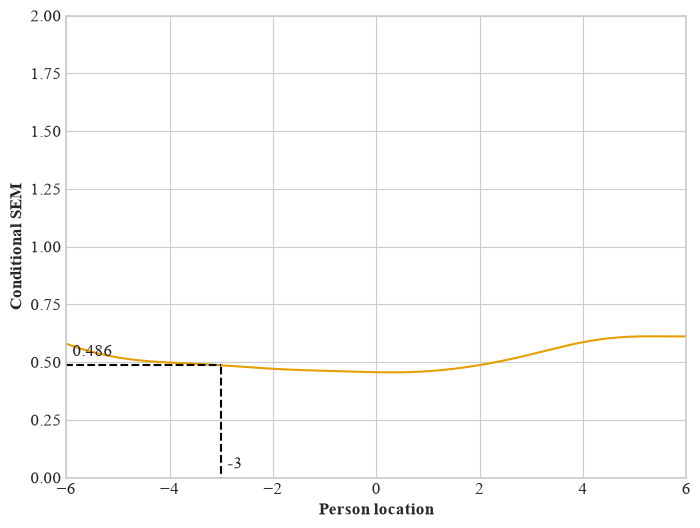

In [32]:
rsm.test_csem(point_csem_lines=[-3], point_csem_labels=True, xmin=-6, xmax=6, ymax=2, filename='my_rsm_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

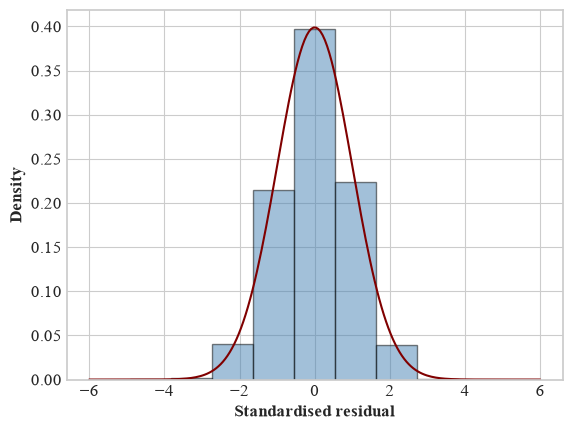

In [33]:
rsm.std_residuals_plot(bin_width=0.6, normal=True, filename='my_rsm_std_residuals_plot')

Produce a Wright map, showing the person location distribution alongside an item strip (one row per item, divided into its own category segments at each Rasch-Andrich threshold), with mean/±1SD/±2SD reference marks for persons

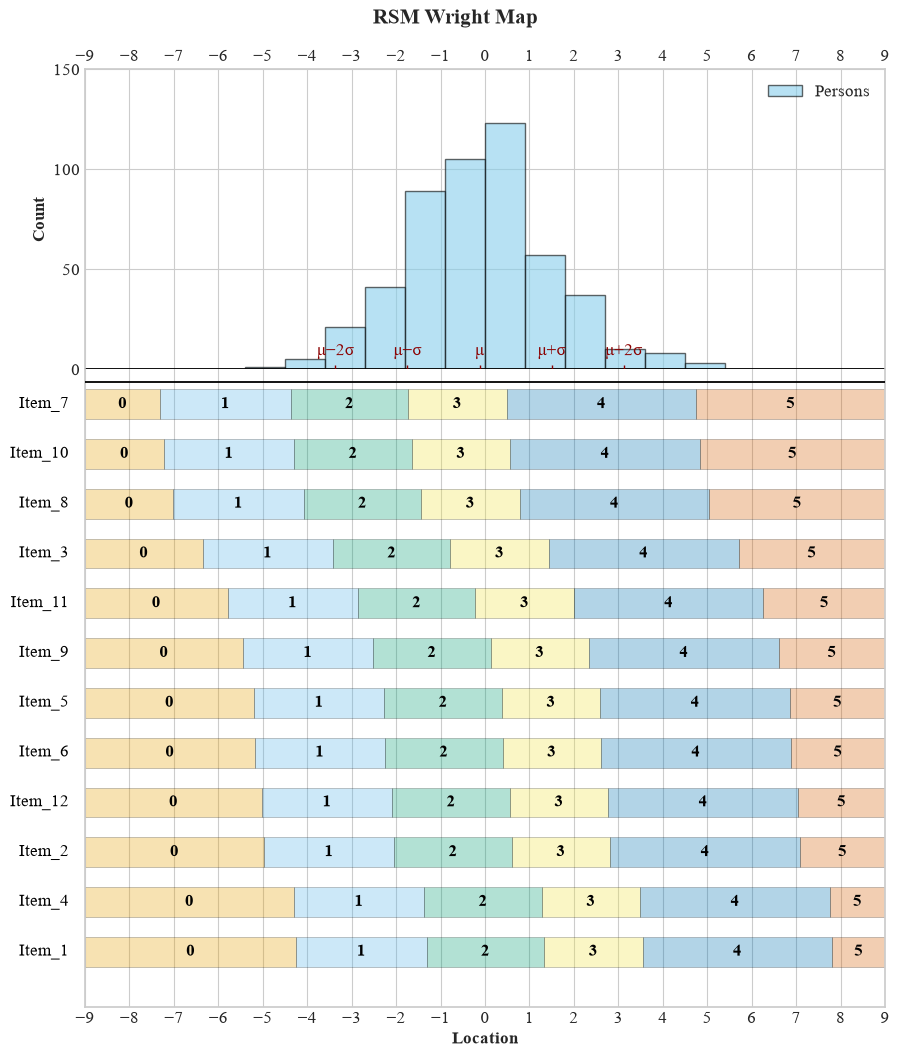

In [34]:
rsm.wright_map(item_strip=True, distribution_markers=True, title='RSM Wright Map', filename='my_rsm_wright_map')